# Fourier Transform and Fast Fourier Transform (FFT)

## Objective

In this notebook, we will learn how a signal in the **time domain** can be represented in the **frequency domain** using the Fourier Transform.

We will:

1. Generate a signal composed of multiple sine waves.
2. Understand the mathematical representation of the signal.
3. Explain the Continuous Fourier Transform.
4. Introduce the Discrete Fourier Transform (DFT).
5. Compute the Fast Fourier Transform (FFT) using Python.
6. Interpret the frequency spectrum.



In [27]:
import numpy as np
import scipy as scp
import sympy as sp
import matplotlib.pyplot as plt
from  scipy.fft  import fft,fftfreq
import scienceplots 
import warnings

warnings.filterwarnings("ignore")


In [28]:
from sympy.abc import t,f

In [29]:
y=sp.exp(-4*t)*sp.Heaviside(t)

In [36]:
y

exp(-4*t)*Heaviside(t)

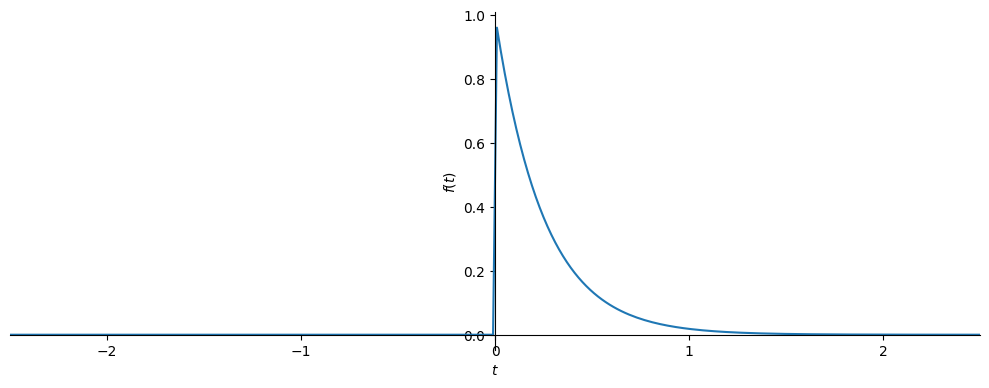

In [37]:
sp.plot(y,xlim=[-2.5,2.5])
plt.show()

In [38]:
y_f=sp.fourier_transform(y,t,f)

In [40]:
y_f

1/(2*(I*pi*f + 2))

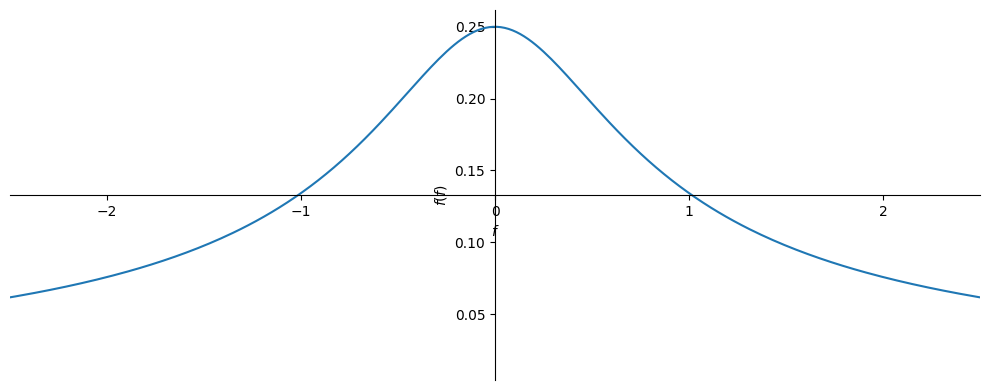

In [43]:
sp.plot(sp.Abs(y_f),xlim=[-2.5,2.5])
plt.show()

In [44]:
rect_pulse=sp.Heaviside(t+4)-sp.Heaviside(t-4)

In [45]:
rect_pulse


-Heaviside(t - 4) + Heaviside(t + 4)

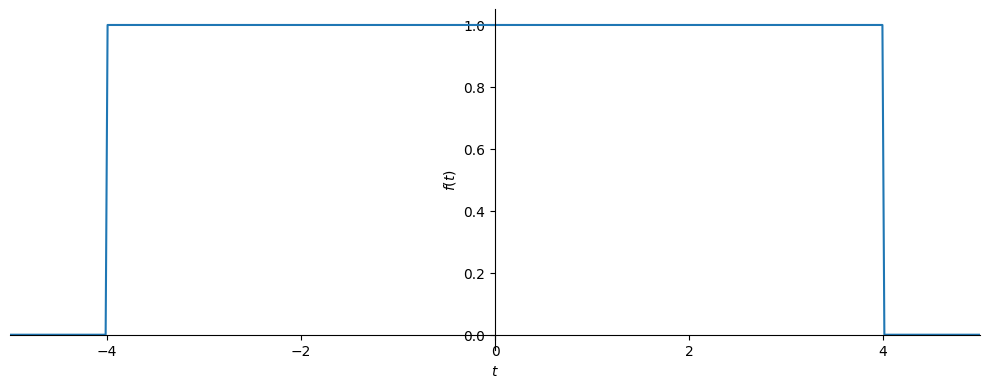

In [48]:
sp.plot(rect_pulse,xlim=[-5,5])
plt.show()

In [49]:
rect_pulse_f=sp.fourier_transform(rect_pulse,t,f)

In [50]:
rect_pulse_f

sin(8*pi*f)/(pi*f)

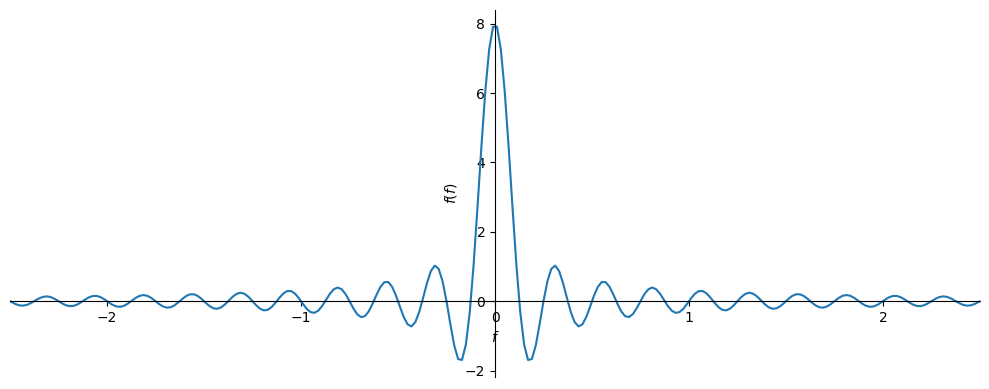

In [53]:
sp.plot(rect_pulse_f,xlim=[-2.5,2.5])
plt.show()

$\frac{sin(8\pi f)}{\pi f}$=$8sinc(8\pi f)$

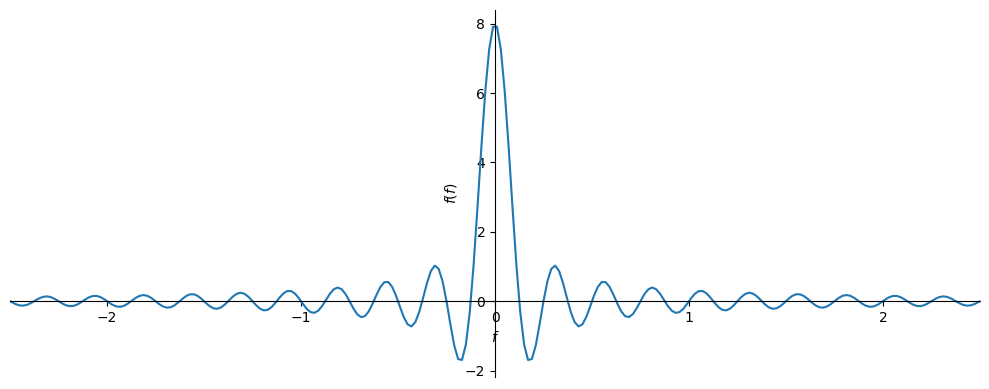

In [54]:
sp.plot(8*sp.sinc(8*sp.pi*f),xlim=[-2.5,2.5])
plt.show()

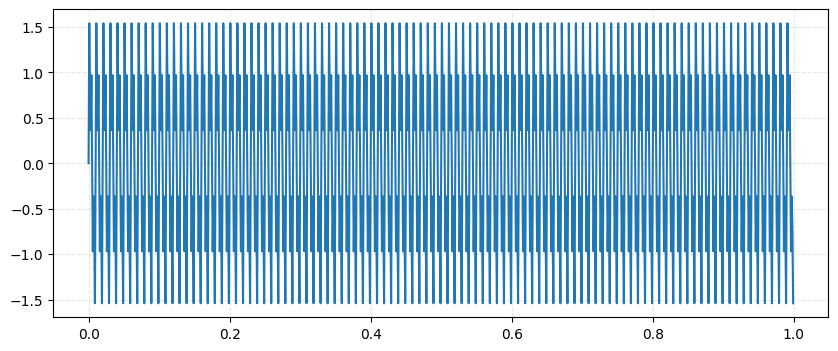

In [72]:
Fs=1000
T=1/Fs
N=1000
t=np.arange(N)*T

signals=(
    np.sin(2*np.pi*100*t)+
    0.7*np.sin(2*np.pi*300*t)+
    0.3*np.sin(2*np.pi*200*t)
)

plt.plot(t,signals)
plt.grid(True,linestyle="--",alpha=0.3)
plt.show()

<StemContainer object of 3 artists>

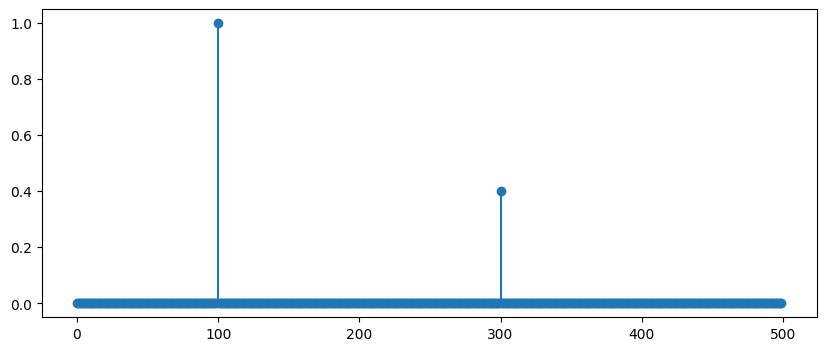

In [71]:
X=fft(signals)
freq=fftfreq(N,T)
mag=2/N*np.abs(X)

plt.stem(freq[:N//2],mag[:N//2],basefmt=" ")